## Testing microsoft/git-base

In [1]:
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image
import torch

# Load model and processor
model_name = "microsoft/git-base"
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Load an image
image_path = 'Albums/Birthday/3033433439.jpg'#"P6.jpeg"  # Change this to your image path
image = Image.open(image_path).convert("RGB")

# Process image
inputs = processor(images=image, return_tensors="pt")

# Generate text
with torch.no_grad():
    generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=50)
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

# Output the generated caption
print("Generated Text:", generated_text)

c:\Users\Matthew\miniconda3\envs\pytdml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Legacy behavior is being used. The current behavior will be deprecated in version 5.0.0. In the new behavior, if both images and text are provided, the last token (EOS token) of the input_ids and attention_mask tensors will be removed. To test the new behavior, set `legacy=False`as a processor call argument.


Generated Text: the white building in the background is the national bank building.


## Testing K-MEANS

Best resizing dimensions: 500x375


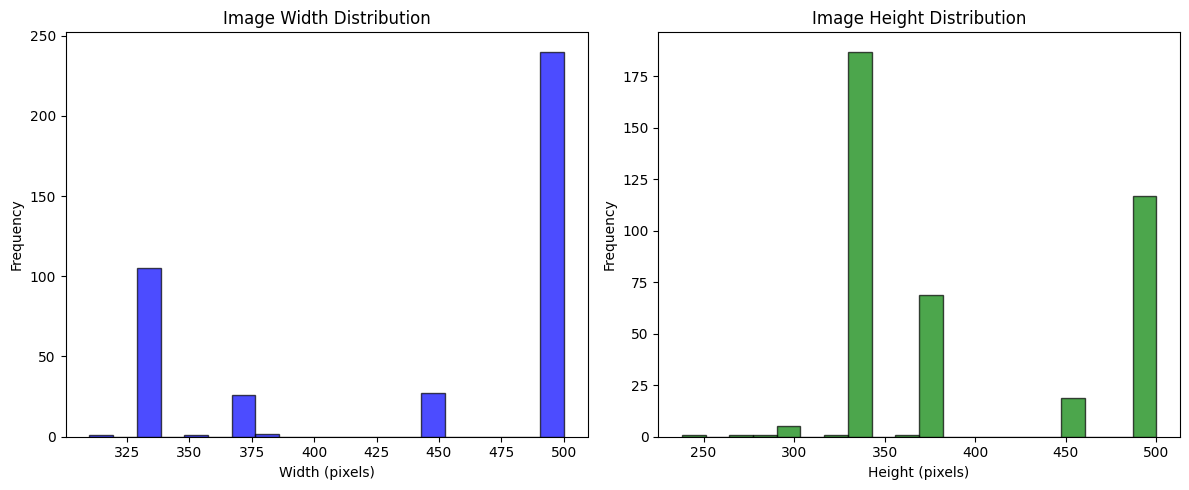

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

def analyze_image_sizes(root_folder):
    """
    Analyzes all images in the given folder and determines the best resizing size
    based on the median dimensions of all images.

    Parameters:
        root_folder (str): The path to the root folder containing images.

    Returns:
        tuple: (best_width, best_height)
    """
    widths = []
    heights = []
    
    # Scan all subfolders
    for subfolder in os.listdir(root_folder):
        subfolder_path = os.path.join(root_folder, subfolder)
        if os.path.isdir(subfolder_path):
            for file in os.listdir(subfolder_path):
                file_path = os.path.join(subfolder_path, file)
                try:
                    with Image.open(file_path) as img:
                        width, height = img.size
                        widths.append(width)
                        heights.append(height)
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

    if not widths or not heights:
        print("No images found!")
        return None

    # Compute the best resizing size (median dimensions)
    best_width = int(np.median(widths))
    best_height = int(np.median(heights))

    print(f"Best resizing dimensions: {best_width}x{best_height}")

    # Visualize the distribution of image sizes
    visualize_image_sizes(widths, heights)

    return best_width, best_height


def visualize_image_sizes(widths, heights):
    """
    Creates histograms for image widths and heights to visualize size distribution.

    Parameters:
        widths (list): List of image widths.
        heights (list): List of image heights.
    """
    plt.figure(figsize=(12, 5))

    # Plot Widths
    plt.subplot(1, 2, 1)
    plt.hist(widths, bins=20, color="blue", alpha=0.7, edgecolor="black")
    plt.xlabel("Width (pixels)")
    plt.ylabel("Frequency")
    plt.title("Image Width Distribution")

    # Plot Heights
    plt.subplot(1, 2, 2)
    plt.hist(heights, bins=20, color="green", alpha=0.7, edgecolor="black")
    plt.xlabel("Height (pixels)")
    plt.ylabel("Frequency")
    plt.title("Image Height Distribution")

    plt.tight_layout()
    plt.show()


# Example usage
root_folder = "./Albums"  # Change this to your dataset path
best_size = analyze_image_sizes(root_folder)


Loading images...
Clustering with K-Means...
Clustering accuracy: 44.28%
Clusters saved to clusters.txt


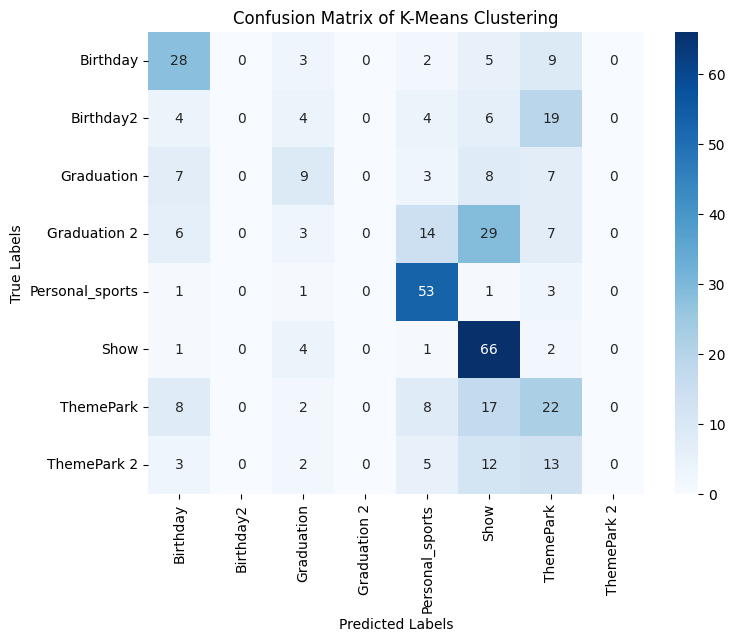

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import Counter
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Function to load images from subfolders and preprocess them
def load_images_from_folder(root_folder, image_size=(500 , 375)):
    """
    Loads images from subfolders, converts them to grayscale, resizes them,
    and flattens them into feature vectors.

    Parameters:
        root_folder (str): The path to the main folder containing subfolders of images.
        image_size (tuple): The fixed size to which images are resized.

    Returns:
        np.array: Image feature vectors.
        np.array: Corresponding labels.
        list: Names of subfolders (classes).
    """
    image_data = []  # Stores flattened pixel values of images
    labels = []  # Stores the numeric labels for each image
    label_names = []  # Stores the actual subfolder (category) names

    # Loop through subfolders (each representing a different category)
    for label, subfolder in enumerate(os.listdir(root_folder)):
        subfolder_path = os.path.join(root_folder, subfolder)
        if os.path.isdir(subfolder_path):
            label_names.append(subfolder)  # Store subfolder name as a label
            for file in os.listdir(subfolder_path):
                file_path = os.path.join(subfolder_path, file)
                try:
                    # Open image
                    with Image.open(file_path) as img:
                        img = img.convert("L")  # Convert to grayscale for consistency ---------------------
                        img = img.resize(image_size)  # Resize to a fixed size
                        image_data.append(np.array(img).flatten())  # Flatten pixel values
                        labels.append(label)  # Assign a numeric label
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

    return np.array(image_data), np.array(labels), label_names


# Function to perform clustering and evaluate accuracy
def cluster_images(root_folder, image_size=(500 , 375), save_txt=True):
    """
    Performs K-Means clustering on images and evaluates accuracy.

    Parameters:
        root_folder (str): Path to dataset root folder.
        image_size (tuple): Size to which images are resized.
        save_txt (bool): Whether to save cluster assignments in a text file.

    Returns:
        tuple: (K-Means model, accuracy score)
    """
    print("Loading images...")
    X, y_true, label_names = load_images_from_folder(root_folder, image_size)

    print("Clustering with K-Means...")
    kmeans = KMeans(n_clusters=len(label_names), random_state=42, n_init=10)
    y_pred = kmeans.fit_predict(X)

    # Create mapping from cluster ID to true label using majority voting
    cluster_to_label = {}
    for cluster in range(len(label_names)):
        cluster_indices = np.where(y_pred == cluster)[0]  # Get indices of images in this cluster
        true_labels_in_cluster = y_true[cluster_indices]  # Get true labels
        if len(true_labels_in_cluster) > 0:
            # Assign cluster to the most frequent true label in it
            most_common_label = Counter(true_labels_in_cluster).most_common(1)[0][0]
            cluster_to_label[cluster] = most_common_label

    # Convert predicted clusters into corresponding labels
    y_pred_mapped = np.array([cluster_to_label[c] for c in y_pred])

    # Calculate clustering accuracy
    accuracy = accuracy_score(y_true, y_pred_mapped)
    print(f"Clustering accuracy: {accuracy:.2%}")

    # Save clustering results to a text file
    if save_txt:
        with open("clusters.txt", "w") as f:
            for i, (pred, true) in enumerate(zip(y_pred, y_true)):
                f.write(f"Image {i}: Cluster {pred}, True Label {true} ({label_names[true]})\n")
        print("Clusters saved to clusters.txt")

    # Show confusion matrix
    plot_confusion_matrix(y_true, y_pred_mapped, label_names)

    return kmeans, accuracy


# Function to plot a confusion matrix
def plot_confusion_matrix(y_true, y_pred, label_names):
    """
    Plots a confusion matrix to show clustering performance.

    Parameters:
        y_true (np.array): True labels.
        y_pred (np.array): Predicted cluster labels.
        label_names (list): List of label names.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix of K-Means Clustering")
    plt.show()


# Example usage
root_folder = "./Albums"
kmeans_model, acc = cluster_images(root_folder, image_size=(500 , 375), save_txt=True)


## Testing HDBSCAN

Loading images...
Clustering with HDBSCAN...
Clustering accuracy (excluding noise points): 24.56%
Clusters saved to clusters_hdbscan.txt


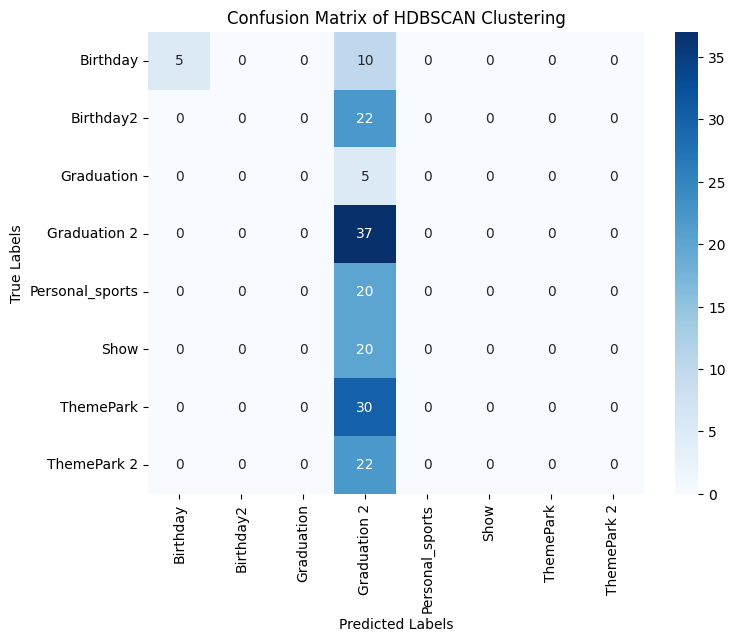

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import hdbscan  # Import HDBSCAN
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import Counter
import pandas as pd

# Function to load images from subfolders and preprocess them
def load_images_from_folder(root_folder, image_size=(500 , 375)):
    """
    Loads images from subfolders, converts them to grayscale, resizes them,
    and flattens them into feature vectors.

    Parameters:
        root_folder (str): The path to the main folder containing subfolders of images.
        image_size (tuple): The fixed size to which images are resized.

    Returns:
        np.array: Image feature vectors.
        np.array: Corresponding labels.
        list: Names of subfolders (classes).
    """
    image_data = []  # Stores flattened pixel values of images
    labels = []  # Stores the numeric labels for each image
    label_names = []  # Stores the actual subfolder (category) names

    # Loop through subfolders (each representing a different category)
    for label, subfolder in enumerate(os.listdir(root_folder)):
        subfolder_path = os.path.join(root_folder, subfolder)
        if os.path.isdir(subfolder_path):
            label_names.append(subfolder)  # Store subfolder name as a label
            for file in os.listdir(subfolder_path):
                file_path = os.path.join(subfolder_path, file)
                try:
                    # Open image
                    with Image.open(file_path) as img:
                        img = img.convert("L")  # Convert to grayscale for consistency
                        img = img.resize(image_size)  # Resize to a fixed size
                        image_data.append(np.array(img).flatten())  # Flatten pixel values
                        labels.append(label)  # Assign a numeric label
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

    return np.array(image_data), np.array(labels), label_names


# Function to perform clustering using HDBSCAN
def cluster_images(root_folder, image_size=(500 , 375), save_txt=True):
    """
    Performs HDBSCAN clustering on images and evaluates accuracy.

    Parameters:
        root_folder (str): Path to dataset root folder.
        image_size (tuple): Size to which images are resized.
        save_txt (bool): Whether to save cluster assignments in a text file.

    Returns:
        tuple: (HDBSCAN model, accuracy score)
    """
    print("Loading images...")
    X, y_true, label_names = load_images_from_folder(root_folder, image_size)

    print("Clustering with HDBSCAN...")
    hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3)  # Adjust parameters as needed
    y_pred = hdbscan_model.fit_predict(X)

    # Identify and filter out noise points (-1 label)
    valid_indices = y_pred != -1
    y_pred_filtered = y_pred[valid_indices]
    y_true_filtered = y_true[valid_indices]

    # Create mapping from cluster ID to true label using majority voting
    cluster_to_label = {}
    unique_clusters = np.unique(y_pred_filtered)
    for cluster in unique_clusters:
        cluster_indices = np.where(y_pred_filtered == cluster)[0]
        true_labels_in_cluster = y_true_filtered[cluster_indices]
        if len(true_labels_in_cluster) > 0:
            most_common_label = Counter(true_labels_in_cluster).most_common(1)[0][0]
            cluster_to_label[cluster] = most_common_label

    # Convert predicted clusters into corresponding labels
    y_pred_mapped = np.array([cluster_to_label.get(c, -1) for c in y_pred_filtered])

    # Calculate clustering accuracy only for assigned clusters (excluding noise points)
    accuracy = accuracy_score(y_true_filtered, y_pred_mapped)
    print(f"Clustering accuracy (excluding noise points): {accuracy:.2%}")

    # Save clustering results to a text file
    if save_txt:
        with open("clusters_hdbscan.txt", "w") as f:
            for i, (pred, true) in enumerate(zip(y_pred, y_true)):
                f.write(f"Image {i}: Cluster {pred}, True Label {true} ({label_names[true] if true != -1 else 'Noise'})\n")
        print("Clusters saved to clusters_hdbscan.txt")

    # Show confusion matrix
    plot_confusion_matrix(y_true_filtered, y_pred_mapped, label_names)

    return hdbscan_model, accuracy


# Function to plot a confusion matrix
def plot_confusion_matrix(y_true, y_pred, label_names):
    """
    Plots a confusion matrix to show clustering performance.

    Parameters:
        y_true (np.array): True labels.
        y_pred (np.array): Predicted cluster labels.
        label_names (list): List of label names.
    """
    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix of HDBSCAN Clustering")
    plt.show()


# Example usage
root_folder = "./Albums"
hdbscan_model, acc = cluster_images(root_folder)
